In [3]:
"""This mudol is for week 4 session 3"""

# imports
import numpy as np

# Question 1

In [ ]:
# variables
arr = np.random.randn(10000, 6)
arr_shufle = np.random.permutation(len(arr))

training_set = arr[arr_shufle[:8000], :]
test_set = arr[arr_shufle[8000:9000], :]
validation_set = arr[arr_shufle[9000:], :]
# outputs of train and test shape
print(f"Training samples:{training_set.shape[0]}")
print(f"Validation samples: {test_set.shape[0]}")
print(f"Test samples:{validation_set.shape[0]}")
print(f"total:{len(arr_shufle)}")


arr1 = np.random.randn(12350, 6)
arr_shufle = np.random.permutation(len(arr1))

first_percentage = len(arr1) * 80 // 100
second_percentage = len(arr1) * 10 // 100


print(f"first_percentage:{first_percentage}")
print(f"second_percentage:{second_percentage}")

training_set = arr1[arr_shufle[:first_percentage], :]
test_set = arr1[
    arr_shufle[first_percentage : (first_percentage + second_percentage)], :
]
validation_set = arr1[arr_shufle[first_percentage + second_percentage :], :]

print(training_set.shape)
print(test_set.shape)
print(validation_set.shape)
print(f"sum : {len(training_set) + len(test_set) + len(validation_set)}")

Training samples:8000
Validation samples: 1000
Test samples:1000
total:10000
first_percentage:9880
second_percentage:1235
(9880, 6)
(1235, 6)
(1235, 6)
sum : 12350


# Question 2

In [ ]:
# variables
ground_truth = np.array(
    ["Normal", "Urgent", "Normal", "Spam", "Urgent", "Normal", "Spam", "Normal"]
)

predictions = np.array(
    ["Normal", "Normal", "Normal", "Spam", "Urgent", "Spam", "Spam", "Normal"]
)

print(f"ground truth :\n{ground_truth}\nprediction :\n{predictions}")

mask = predictions == ground_truth
print(f"mask: \n{mask}")
true_predict = np.sum(mask)
false_predict = len(mask) - true_predict
print(f"sum of true predict: {true_predict}\nsum of false predict: {false_predict}")
# grand truth : لیبل های حقیقی داده هایی که مدل سعی کرده لیبل آنها رو پیش بینی کنه
# prediction : لیبل هایی که مدل سعی داشته پیش بینی کنه بر اساس الگویی که از داده ها کشف کرده

ground truth :
['Normal' 'Urgent' 'Normal' 'Spam' 'Urgent' 'Normal' 'Spam' 'Normal']
prediction :
['Normal' 'Normal' 'Normal' 'Spam' 'Urgent' 'Spam' 'Spam' 'Normal']
mask: 
[ True False  True  True  True False  True  True]
sum of true predict: 6
sum of false predict: 2


grand truth : لیبل های حقیقی داده هایی که مدل سعی کرده لیبل آنها رو پیش بینی کنه 
prediction : لیبل هایی که مدل سعی داشته پیش بینی کنه بر اساس الگویی که از داده ها کشف کرده 

# Question 3

In [ ]:
accuracy = true_predict / len(mask)
accuracy_percent = true_predict / len(mask) * 100
print(f"Accuracy: {accuracy}")
print(f"Accuracy percent: {accuracy_percent}%")

error_rate = false_predict / len(mask)
error_rate_percent = false_predict / len(mask) * 100
# error_rate = 100 - accuracy
print(f"Error: {error_rate}")
print(f"Error percent: {error_rate_percent}%")

print(f"is accuracy + error_rate = 1? {accuracy + error_rate == 1}")

# 5 => 8%
# 6 => 65%

Accuracy: 0.75
Accuracy percent: 75.0%
Error: 0.25
Error percent: 25.0%
is accuracy + error_rate = 1? True


# Question 4

In [5]:
y_true = np.array(["normal"] * 950 + ["urgent"] * 50)
y_pred = np.array(["normal"] * 1000)
mask = y_true == y_pred
true_predict = np.sum(mask)
false_predict = len(mask) - np.sum(mask)
accuracy = true_predict / len(mask)
error_rate = false_predict / len(mask)
print(f"false_predict:{false_predict}")

# باعث ایجاد تشخیص نادرست میشه
# داده ها متعادل نیستند - باید دقت هر دو لیبل محاسبه میشد ولی در اینجا فقط نرمال حساب شده

false_predict:50


# Question 5

In [ ]:
# functions
def accuracy(ytrue, ypred):
    correct = np.sum(ytrue == ypred)
    acc = correct / len(ytrue)

    return acc, 1 - acc


# variables
patient_id = np.array([1, 2, 3, 4, 5])
# y true | target class => Malignant
ground_truth = np.array(["Healthy", "Malignant", "Healthy", "Healthy", "Malignant"])
# y pred
predictions = np.array(["Healthy", "Malignant", "Malignant", "Healthy", "Healthy"])

# preditction was right?
error = ground_truth == predictions
print(f"predictions was right? for each patient:\n{error}")
# measure accuracy
accuracy_patient = accuracy(ground_truth, predictions)[0]
error_rate = accuracy(ground_truth, predictions)[1]
print(f"accuracy = {accuracy_patient*100:.2f}%")
print(f"error rate = {error_rate*100:.2f}%")
# sum of False positive
ground_check = ground_truth == "Healthy"
false_positive = 0
fp_idx = []
for i, check in enumerate(ground_check):
    if check:
        if predictions[i] != "Healthy":
            false_positive += 1
            fp_idx.append(i)
            print(f"y true was {ground_truth[i]} prediction was {predictions[i]}")

print(f"Sum fp: {false_positive}")

# sum of False negative
ground_check = ground_truth == "Malignant"
false_negative = 0
fn_idx = []
for i, check in enumerate(ground_check):
    if check:
        if predictions[i] != "Malignant":
            false_negative += 1
            fn_idx.append(i)
            print(f"y true was {ground_truth[i]} prediction was {predictions[i]}")

print(f"Sum fn: {false_negative}")
for i in fp_idx:
    print(f"\npatient id {patient_id[i]} was False positive")
for i in fn_idx:
    print(f"patient id {patient_id[i]} was False negative")

predictions was right? for each patient:
[ True  True False  True False]
accuracy = 60.00%
error rate = 40.00%
y true was Healthy prediction was Malignant
Sum fp: 1
y true was Malignant prediction was Healthy
Sum fn: 1

patient id 3 was False positive
patient id 5 was False negative


در یک سیستم درمانی کم  بودن فاصل نگاتیو خیلی مهم تر است چرا که به معنای تشخیص حداکثری افراد بیمار است 

بالا بودن اکیوریسی همیشه خوب نیست چون معیار خوبی برای تشخیص نوع خطای مدل نیست و همچنین در کلاس های نابرابر باعث ایجاد درک غلط میشود

# Question 6

In [ ]:
# functions
def accuracy(ytrue, ypred):
    correct = np.sum(ytrue == ypred)
    acc = correct / len(ytrue)

    return acc, 1 - acc


# variables
email_id = np.array([1, 2, 3, 4, 5])
# Main Class => Spam
ground_truth = np.array(["Not Spam", "Spam", "Not Spam", "Not Spam", "Spam"])
predictions = np.array(["Not Spam", "Spam", "Spam", "Not Spam", "Not Spam"])

# prediction was right?
error_check = ground_truth == predictions
print(f"prediction was right ?(for each email): \n{error_check}")

# measure accuracy
email_accuracy = accuracy(ground_truth, predictions)[0]
email_error_rate = accuracy(ground_truth, predictions)[1]

print(
    f"{"accuracy  ":<12}: %{email_accuracy*100:.2f}\n{"error rate ":<12}: %{email_error_rate*100:.2f}"
)
# False Positive
ground_check = ground_truth == "Not Spam"
false_positive = 0
fp_idx = []
for i, check in enumerate(ground_check):
    if check:
        if predictions[i] == "Spam":
            false_positive += 1
            fp_idx.append(i)

print(f"Sum of False Positive = {false_positive}")

# False Negative
ground_check = ground_truth == "Spam"
false_negative = 0
fn_idx = []
for i, check in enumerate(ground_check):
    if check:
        if predictions[i] == "Not Spam":
            false_negative += 1
            fn_idx.append(i)

print(f"Sum of False Negative = {false_negative}")


print(f"Sum fn: {false_negative}")
for i in fp_idx:
    print(f"\npatient id {patient_id[i]} was False positive")
for i in fn_idx:
    print(f"patient id {patient_id[i]} was False negative")

prediction was right ?(for each email): 
[ True  True False  True False]
accuracy    : %60.00
error rate  : %40.00
Sum of False Positive = 1
Sum of False Negative = 1
Sum fn: 1

patient id 3 was False positive
patient id 5 was False negative


در اینجا برعکس مسئله درمانی ایمیل نباید به اشتباه اسپم شناخته شود چون ممکن است یک ایمیل مهم کاری از جانب کارفرما باشد 

پس در اینجا فالس پازتیو مهم تر است 

# Question 7

In [ ]:
# features
study_hours = np.array([1, 2, 3, 5, 7, 8])
gaming_hours = np.array([6, 5, 4, 3, 2, 1])
actual_scores = np.array([35, 40, 50, 68, 82, 90])
# model params
weight1 = 8
# gaming hours has negative effect to final score
# so the weight is negative
weight2 = -3
bias = 45

# model predict just in range 0 to 100
ypred = np.clip(
    (study_hours * weight1) + (gaming_hours * weight2) + bias, a_min=0, a_max=100
)

# regression error
reg_error = actual_scores - ypred
print(f"regression error (sample by sample) = \n{reg_error}")
# absolute error
abs_error = np.abs(reg_error)
print(f"regression absolute error (sample by sample) = \n{abs_error}")
# MAE score
mae_score = np.mean(abs_error)
print(f"MAE score for this model on this dataset: {mae_score:.2f}")

regression error (sample by sample) = 
[  0  -6  -7  -8 -13 -10]
regression absolute error (sample by sample) = 
[ 0  6  7  8 13 10]
MAE score for this model on this dataset: 7.33


weight 1 is positive because it has positive effect on output 
- More study hours => More final score.

weight 2 is negative because it has negative effect on output
- More gaming hours => Less final score

Bias is the base score that every body could earn with out reading for exam 

# Question 8

In [ ]:
# functions
def predict(weight1, weight2):

    return


# variable
candidate_weight1 = np.array([2, 4, 6, 8, 10, 12])
weight2 = -3
bias = 45

# test different weights
test_weight1 = np.clip(
    (study_hours * candidate_weight1.reshape(6, 1)) + (gaming_hours * weight2) + bias,
    a_min=0,
    a_max=100,
)

errors = test_weight1 - actual_scores
abs_errors = np.abs(errors)
mae_scores = np.mean(abs_errors, axis=1)

print(f"errors :\n{errors}\nabs errors:\n{abs_errors}")
for mae_score in mae_scores:
    print(f"MAE scores:{mae_score:.2f}\n")

# best weight1
mae_min_idx = mae_scores.argmin()
best_weight1 = candidate_weight1[mae_min_idx]
print(f"candidate weight1:\n{candidate_weight1}")
print(f"best value for weight1 = {best_weight1}\
\nwith MAE = {mae_scores[mae_min_idx]:.2f}")

errors :
[[ -6  -6 -11 -22 -29 -32]
 [ -4  -2  -5 -12 -15 -16]
 [ -2   2   1  -2  -1   0]
 [  0   6   7   8  13  10]
 [  2  10  13  18  18  10]
 [  4  14  19  28  18  10]]
abs errors:
[[ 6  6 11 22 29 32]
 [ 4  2  5 12 15 16]
 [ 2  2  1  2  1  0]
 [ 0  6  7  8 13 10]
 [ 2 10 13 18 18 10]
 [ 4 14 19 28 18 10]]
MAE scores:17.67

MAE scores:9.00

MAE scores:1.33

MAE scores:7.33

MAE scores:11.83

MAE scores:15.50

candidate weight1:
[ 2  4  6  8 10 12]
best value for weight1 = 6
with MAE = 1.33


# Question 9

In [15]:
# variables
emails = np.array(
    [
        "URGENT reset my password now!!!",
        "hello I have a question about my invoice",
        "refund refund refund this is unacceptable!!!",
        "please cancel my subscription",
        "thank you for your help",
        "URGENT billing error please help!!!",
    ]
)
labels = np.array(["Urgent", "Normal", "Urgent", "Normal", "Normal", "Urgent"])
# feature extraction
from collections import Counter

X_new_feat = np.zeros((len(emails), 4))
for i, text in enumerate(emails):
    if "urgent" in text.lower():
        X_new_feat[i, 0] = 1
    if "refund" in text.lower():
        X_new_feat[i, 1] = 1
    X_new_feat[i, 2] = Counter(text)["!"]
    X_new_feat[i, 3] = len(text.replace("!", " ").split())

print(f"features:\n{X_new_feat}")

features:
[[1. 0. 3. 5.]
 [0. 0. 0. 8.]
 [0. 1. 3. 6.]
 [0. 0. 0. 4.]
 [0. 0. 0. 5.]
 [1. 0. 3. 5.]]


# Quesiton 10 

In [29]:
# rules
# urgent_word == 1
# refund_word == 1
# exclamation_count >= 3
mask = (X_new_feat[:, 0] == 1) | (X_new_feat[:, 1] == 1) | (X_new_feat[:, 2] >= 3)

ypred = np.where(mask == True, "Urgent", "Normal")
print(f"rule based system prediction :\n{ypred}")

error_check = labels == ypred
acc = np.sum(error_check) / len(labels)
error_rate = 1 - acc

print(f"Accuracy = {acc*100:.2f}%\nerror rate : {error_rate*100:.2f}%")

rule based system prediction :
['Urgent' 'Normal' 'Urgent' 'Normal' 'Normal' 'Urgent']
Accuracy = 100.00%
error rate : 0.00%


# Question 11

In [ ]:
# varialbes
X = np.array([1, 2, 3, 4, 5])
y = np.array([3, 6, 9, 12, 15])
# prediction variable
candidate_w = np.array([1, 2, 2.5, 3, 3.5, 4])
prediction = X * candidate_w.reshape(len(candidate_w), 1)

# MSE
mse = np.mean((prediction - y) ** 2, axis=1)
mse_min_idx = mse.argmin()
best_weight = candidate_w[mse_min_idx]
print(f"Best MSE is {mse[mse_min_idx]}\n\
best weight is {candidate_w[mse_min_idx]}")

Best MSE is 0.0
best weight is 3.0


# Question 12

In [ ]:
# variables
epochs = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
train_accuracy = np.array([0.55, 0.63, 0.70, 0.78, 0.85, 0.90, 0.94, 0.97, 0.99, 1.00])
validation_accuracy = np.array(
    [0.52, 0.60, 0.68, 0.75, 0.82, 0.84, 0.83, 0.79, 0.74, 0.70]
)
best_epoch_idx = validation_accuracy.argmax()
best_epoch = epochs[best_epoch_idx]

print(f"best epoch to fit model is : {best_epoch}\n\
Test accuracy on this epoch : {validation_accuracy[best_epoch_idx]*100}%\n\
Train accuracy on this epoch : {train_accuracy[best_epoch_idx]*100}%")

# after epoch 6 validation acc began
#  to loose and train acc turned bigger.
# That means after epoch 6 model goes to overfitting
# Early stoping means stop learning process to avoid overfitting

best epoch to fit model is : 6
Test accuracy on this epoch : 84.0%
Train accuracy on this epoch : 90.0%


# Question 13

In [12]:
# Q13

import numpy as np

models = np.array(["Model A", "Model B", "Model C"])
train_error = np.array([0.35, 0.08, 0.01])
test_error = np.array([0.38, 0.10, 0.35])
eroor = np.vstack((train_error, test_error))
print(eroor)
gap = test_error - train_error
print(f"gap={gap}")
# min_error_idx=np.argmin(train_error)
mean_error = np.mean(eroor, axis=0)
max_error = np.argmax(mean_error)
max_model_error = models[max_error]

print(f"model with maximum error: {max_model_error}")
# arg_min_train=np.argmin(train_error)
# arg_max_test=np.argmax(test_error)
# if arg_min_train==arg_max_test:
#     print(print(f"model with maximum error: {max_model_error}")
idx = np.argmax(gap)
print(f"overfit model: {models[idx]}")
# به overfitting نزدیکتر است

gap = np.abs(test_error - train_error)
good_idx = np.argmin(test_error + gap)
print("Good Fit:", models[good_idx])

# Underfitting: خطای آموزش زیاد و خطای تست نیز زیاد است.

# Overfitting: خطای آموزش بسیار کم، اما خطای تست به‌مراتب بیشتر از آن است.

# Good fit: هر دو خطا کم و اختلاف آن‌ها اندک است.

[[0.35 0.08 0.01]
 [0.38 0.1  0.35]]
gap=[0.03 0.02 0.34]
model with maximum error: Model A
overfit model: Model C
Good Fit: Model B


سو گیری توسعه دهنده در انتخاب مدل که باعث میشه مدلی انتخاب کنه که ساده  باشه و پیچیدگی کافی برای حل مسئله رو نداشته باشه 

واریانس حساسیت مدل به روبرو شدن با دیتا ست های جدید گفته میشه چرا که مدل حفظ کرده الگوی داده های train رو 

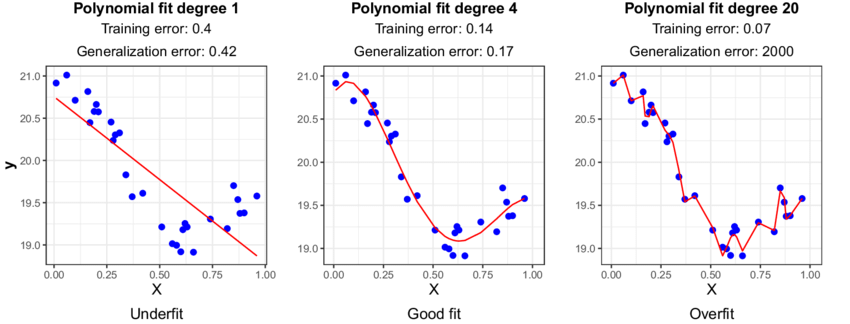

# Question 14

In [40]:
# مدل آ ، بیشترین احتمال بایاس بالا رو داره
# مدل سی ، بیشترین احتمال اورفیت شدن رو داره
# مدل بی ، بهترین فیت رو داشت
# بایاس خطای ناشی از سوگیری
#  توسعه دهنده در انتخاب مدل یا انتخاب دیتاست و فیچر هست
# واریانس خطای مربوط به حساسیت مدل نسبت به تغییر دیتاست هست
# چون مدل ساده نمی تواند الگو های پیچیده
# موجود در داده را درک کند یا داده ها الگو کافی و مشخص و خوبی ندارند
# مدل بیش از حد پیچیده به جای یادگرفتن داده ها ،
#  آنها را حفظ میکند پس با تغییر  داده مدل دیگر نمی تواند پیش بینی نزدیک به واقعیت داشته باشد
# و فقط روی دیتا هایی که آموزش دیده دقت فوق العاده ای دارد

# Question 15

In [ ]:
validation_accuracy = np.array([0.76, 0.82, 0.87, 0.86, 0.84])
test_accuracy = 0.865
model_names = np.array(["Model 1", "Model 2", "Model 3", "Model 4", "Model 5"])
best_validation_idx = validation_accuracy.argmax()
print(f"best  : {model_names[best_validation_idx]}")
print(f"best validation accuracy: {validation_accuracy[best_validation_idx]}")
print(f"test accuracy: {test_accuracy}")

# if test acc was too smaller than validation acc => overfitting
# if test acc and validation acc are near => good fit (if accuracy is not small at all)
# if we use test set in training process , Data leakage will happen.

best  : Model 3
best validation accuracy: 0.87
test accuracy: 0.865


# Question 16

In [ ]:
# study_hours, attendance, previous_score, final_score
students = np.array(
    [
        [2, 60, 45, 50],
        [5, 80, 70, 75],
        [1, 40, 35, 38],
        [8, 90, 88, 92],
        [4, 75, 60, 65],
        [7, 85, 80, 84],
    ]
)
# first three features
X_clean = students[:, :-1]
final_score = students[:, -1]
labels = np.where(final_score >= 60, "pass", "fail")
# leaked dataset
X_leaky = students.copy()
# becaues model can see the result and extract the patern from it
# and when the model see test data in real world can't work
#  becaues real samples does not have last feature

# Question 17

In [ ]:
# Prediction: خروجی‌ای است که مدل برای یک ورودی پیش‌بینی می‌کند.
# Ground Truth: پاسخ واقعی و درستِ داده که مدل باید به آن نزدیک شود.
# Accuracy: نسبت تعداد پیش‌بینی‌های درست به کل نمونه‌ها است.
# Error Rate: نسبت تعداد پیش‌بینی‌های غلط به کل نمونه‌ها است.
# چرا Accuracy همیشه کافی نیست؟: چون در داده‌های نامتوازن ممکن است عدد خوبی بدهد ولی عملکرد واقعی مدل ضعیف باشد.
# False Positive: وقتی مدل اشتباه بگوید نمونه مثبت است در حالی که واقعاً منفی است.
# False Negative: وقتی مدل اشتباه بگوید نمونه منفی است در حالی که واقعاً مثبت است.
# در medical diagnosis کدام error خطرناک‌تر است؟ چرا؟: معمولاً False Negative خطرناک‌تر است چون بیماریِ واقعی را تشخیص نمی‌دهد و درمان عقب می‌افتد.
# Model را چطور می‌توان به صورت mathematical function دید؟: مدل را می‌توان تابعی مثل
# 𝑦
# =
# 𝑓
# (
# 𝑥
# )
# y=f(x)
#  دید که ورودی را به خروجی نگاشت می‌کند.
# Weight و Bias چه نقشی در model دارند؟: وزن‌ها شدت اثر هر ویژگی را تعیین می‌کنند و بایاس خروجی را جابه‌جا یا تنظیم می‌کند.
# Loss چیست؟: معیاری است که میزان خطای مدل را بین پیش‌بینی و مقدار واقعی اندازه می‌گیرد.
# Optimization چیست؟: فرایند تنظیم پارامترهای مدل برای کمینه کردن تابع Loss است.
# چرا preprocessing مهم است؟: چون کیفیت و فرم مناسب داده مستقیماً روی یادگیری و عملکرد مدل اثر می‌گذارد.
# Overfitting چیست؟: حالتی است که مدل داده‌های آموزش را بیش از حد حفظ می‌کند و روی داده جدید بد عمل می‌کند.
# Underfitting چیست؟: حالتی است که مدل آن‌قدر ساده است که حتی الگوی داده آموزش را هم خوب یاد نمی‌گیرد.
# Bias و Variance چه ارتباطی با Underfitting و Overfitting دارند؟: Underfitting معمولاً با Bias بالا و Overfitting معمولاً با Variance بالا همراه است.
# Training Set برای چیست؟: برای آموزش مدل و یادگیری پارامترها استفاده می‌شود.
# Validation Set برای چیست؟: برای تنظیم ابرپارامترها و ارزیابی موقت مدل هنگام توسعه استفاده می‌شود.
# Test Set برای چیست؟: برای سنجش نهایی عملکرد مدل روی داده ندیده استفاده می‌شود.
# Data Leakage چیست؟: ورود ناخواسته اطلاعاتی از بیرونِ فرایند آموزش به مدل است که ارزیابی را غیرواقعی می‌کند.
# Generalization یعنی چه؟: توانایی مدل برای خوب عمل کردن روی داده‌های جدید و ندیده است.